# DCGAN – Handwritten Digit Generation (MNIST)
**Assignment 3 — Deep Learning for Perception**

Reference: Radford et al., arXiv:1511.06434

---
### Quick-start
1. Runtime → Change runtime type → **T4 GPU**
2. Runtime → **Run all**

In [1]:
import os, torch, torch.nn as nn, torch.optim as optim
import torchvision, torchvision.transforms as transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt

LATENT_DIM     = 100
IMAGE_SIZE     = 64
IMAGE_CHANNELS = 1
G_FEATURES     = 64
D_FEATURES     = 64
BATCH_SIZE     = 128
NUM_EPOCHS     = 30
LR             = 0.0002
BETA1          = 0.5
SAVE_INTERVAL  = 5
OUTPUT_DIR     = 'outputs'
os.makedirs(OUTPUT_DIR, exist_ok=True)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')

Device: cuda


In [2]:
def weights_init(m):
    classname = m.__class__.__name__
    if classname.find('Conv') != -1:
        nn.init.normal_(m.weight.data, 0.0, 0.02)
    elif classname.find('BatchNorm') != -1:
        nn.init.normal_(m.weight.data, 1.0, 0.02)
        nn.init.constant_(m.bias.data, 0)

class Generator(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.ConvTranspose2d(LATENT_DIM, G_FEATURES*8, 4, 1, 0, bias=False),
            nn.BatchNorm2d(G_FEATURES*8), nn.ReLU(True),
            nn.ConvTranspose2d(G_FEATURES*8, G_FEATURES*4, 4, 2, 1, bias=False),
            nn.BatchNorm2d(G_FEATURES*4), nn.ReLU(True),
            nn.ConvTranspose2d(G_FEATURES*4, G_FEATURES*2, 4, 2, 1, bias=False),
            nn.BatchNorm2d(G_FEATURES*2), nn.ReLU(True),
            nn.ConvTranspose2d(G_FEATURES*2, G_FEATURES, 4, 2, 1, bias=False),
            nn.BatchNorm2d(G_FEATURES), nn.ReLU(True),
            nn.ConvTranspose2d(G_FEATURES, IMAGE_CHANNELS, 4, 2, 1, bias=False),
            nn.Tanh()
        )
    def forward(self, z):
        return self.net(z)

class Discriminator(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(IMAGE_CHANNELS, D_FEATURES, 4, 2, 1, bias=False),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(D_FEATURES, D_FEATURES*2, 4, 2, 1, bias=False),
            nn.BatchNorm2d(D_FEATURES*2), nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(D_FEATURES*2, D_FEATURES*4, 4, 2, 1, bias=False),
            nn.BatchNorm2d(D_FEATURES*4), nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(D_FEATURES*4, D_FEATURES*8, 4, 2, 1, bias=False),
            nn.BatchNorm2d(D_FEATURES*8), nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(D_FEATURES*8, 1, 4, 1, 0, bias=False),
            nn.Sigmoid()
        )
    def forward(self, x):
        return self.net(x).view(-1)

G = Generator().to(device)
D = Discriminator().to(device)
G.apply(weights_init)
D.apply(weights_init)
print(f'Generator params:     {sum(p.numel() for p in G.parameters()):,}')
print(f'Discriminator params: {sum(p.numel() for p in D.parameters()):,}')

Generator params:     3,574,656
Discriminator params: 2,763,520


In [3]:
transform = transforms.Compose([
    transforms.Resize(IMAGE_SIZE),
    transforms.ToTensor(),
    transforms.Normalize([0.5], [0.5]),
])
dataset    = torchvision.datasets.MNIST('./data', train=True, download=True, transform=transform)
dataloader = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2)
print(f'Dataset size: {len(dataset):,} images')

100%|██████████| 9.91M/9.91M [00:00<00:00, 19.7MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 468kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.49MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 6.97MB/s]

Dataset size: 60,000 images


Epoch [  1/30]  D: 0.5475  G: 5.8302


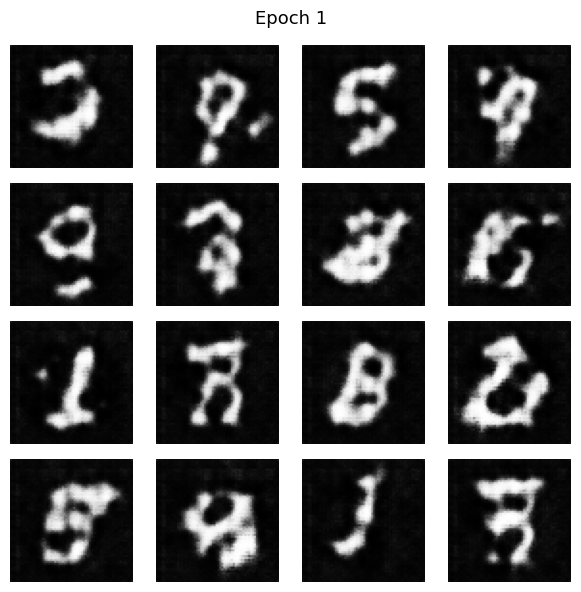

Epoch [  2/30]  D: 0.6961  G: 2.4272
Epoch [  3/30]  D: 0.6235  G: 2.6632
Epoch [  4/30]  D: 0.5287  G: 3.3599
Epoch [  5/30]  D: 0.4973  G: 3.4719


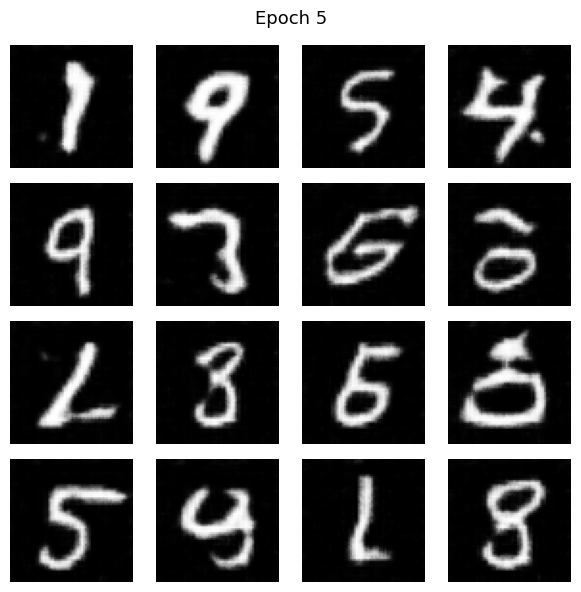

Epoch [  6/30]  D: 0.5034  G: 3.3631
Epoch [  7/30]  D: 0.5877  G: 3.1080
Epoch [  8/30]  D: 0.4378  G: 3.5312
Epoch [  9/30]  D: 0.4762  G: 3.5667
Epoch [ 10/30]  D: 0.6114  G: 3.1219


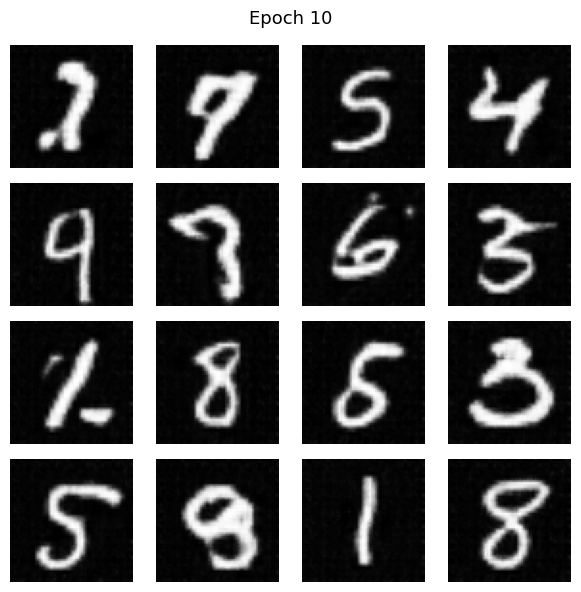

Epoch [ 11/30]  D: 0.4153  G: 3.6181
Epoch [ 12/30]  D: 0.4010  G: 3.6980
Epoch [ 13/30]  D: 0.6000  G: 3.2780
Epoch [ 14/30]  D: 0.3711  G: 3.7882
Epoch [ 15/30]  D: 0.5230  G: 3.4622


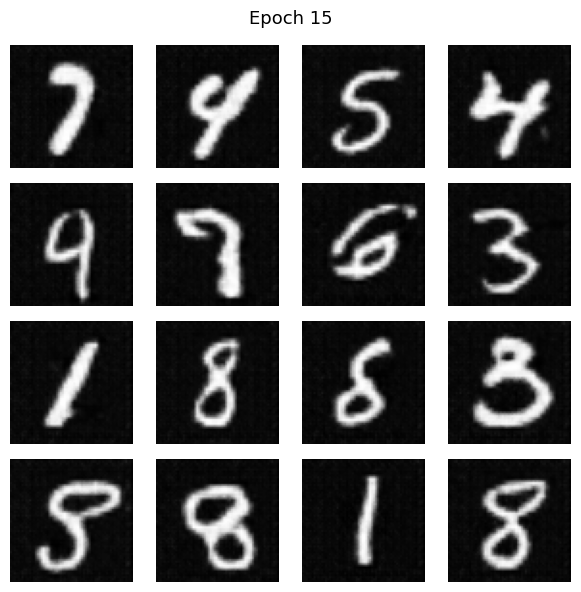

Epoch [ 16/30]  D: 0.2752  G: 3.9464
Epoch [ 17/30]  D: 0.8287  G: 2.7986
Epoch [ 18/30]  D: 0.5060  G: 3.4791
Epoch [ 19/30]  D: 0.4959  G: 3.4222
Epoch [ 20/30]  D: 0.4430  G: 3.6246


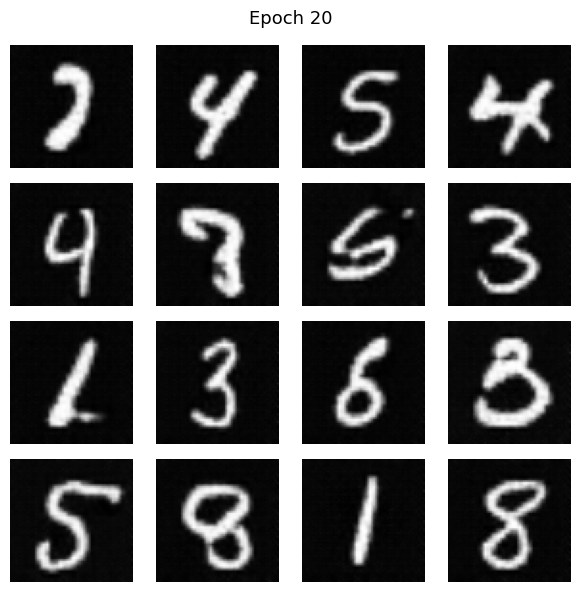

Epoch [ 21/30]  D: 0.4350  G: 3.8001
Epoch [ 22/30]  D: 0.5630  G: 3.4308
Epoch [ 23/30]  D: 0.2667  G: 4.3012
Epoch [ 24/30]  D: 0.4154  G: 3.8353
Epoch [ 25/30]  D: 0.3485  G: 5.6303


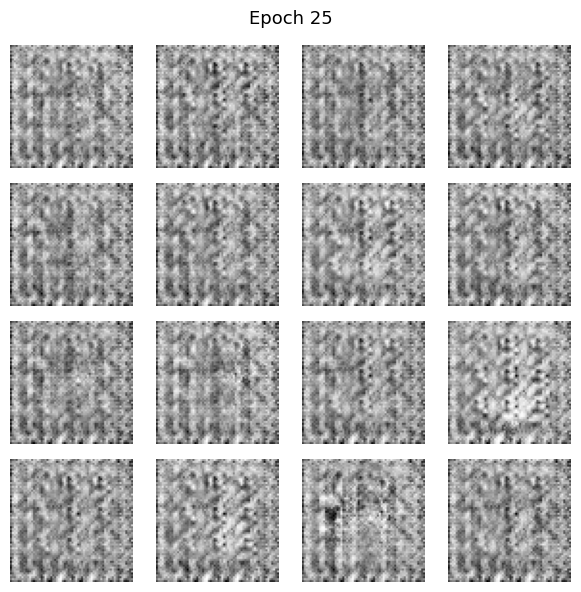

Epoch [ 26/30]  D: 0.0024  G: 8.0801
Epoch [ 27/30]  D: 0.0016  G: 8.6145
Epoch [ 28/30]  D: 0.0016  G: 8.4970
Epoch [ 29/30]  D: 0.0007  G: 8.9801
Epoch [ 30/30]  D: 0.1589  G: 9.1152


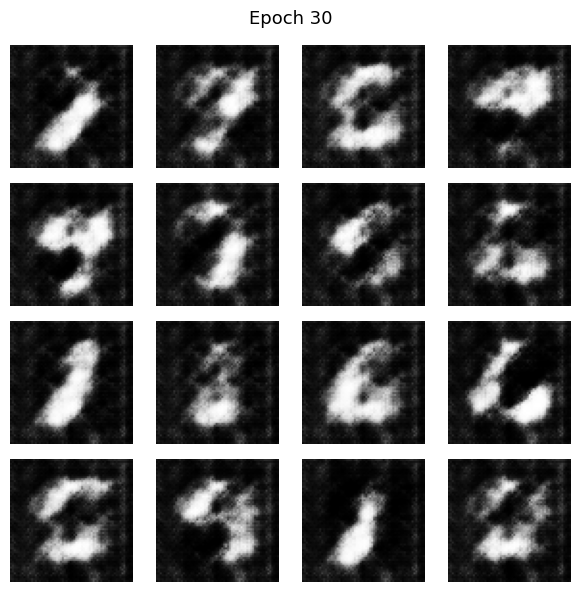

Models saved!


In [4]:
criterion   = nn.BCELoss()
opt_G       = optim.Adam(G.parameters(), lr=LR, betas=(BETA1, 0.999))
opt_D       = optim.Adam(D.parameters(), lr=LR, betas=(BETA1, 0.999))
fixed_noise = torch.randn(16, LATENT_DIM, 1, 1, device=device)
g_losses, d_losses = [], []

def show_samples(epoch):
    G.eval()
    with torch.no_grad():
        fake = (G(fixed_noise).cpu() + 1) / 2
    G.train()
    fig, axes = plt.subplots(4, 4, figsize=(6, 6))
    for i, ax in enumerate(axes.flatten()):
        ax.imshow(fake[i, 0].numpy(), cmap='gray')
        ax.axis('off')
    fig.suptitle(f'Epoch {epoch}', fontsize=13)
    plt.tight_layout()
    plt.savefig(f'{OUTPUT_DIR}/epoch_{epoch:03d}.png', dpi=100)
    plt.show()
    plt.close()

for epoch in range(1, NUM_EPOCHS + 1):
    g_ep, d_ep = 0.0, 0.0
    for real_imgs, _ in dataloader:
        real_imgs = real_imgs.to(device)
        b = real_imgs.size(0)
        ones  = torch.ones(b, device=device)
        zeros = torch.zeros(b, device=device)
        D.zero_grad()
        loss_Dr = criterion(D(real_imgs), ones)
        loss_Dr.backward()
        noise = torch.randn(b, LATENT_DIM, 1, 1, device=device)
        fake  = G(noise)
        loss_Df = criterion(D(fake.detach()), zeros)
        loss_Df.backward()
        opt_D.step()
        G.zero_grad()
        loss_G = criterion(D(fake), ones)
        loss_G.backward()
        opt_G.step()
        g_ep += loss_G.item()
        d_ep += (loss_Dr + loss_Df).item()
        g_losses.append(loss_G.item())
        d_losses.append((loss_Dr + loss_Df).item())
    print(f'Epoch [{epoch:3d}/{NUM_EPOCHS}]  D: {d_ep/len(dataloader):.4f}  G: {g_ep/len(dataloader):.4f}')
    if epoch % SAVE_INTERVAL == 0 or epoch == 1:
        show_samples(epoch)

torch.save(G.state_dict(), f'{OUTPUT_DIR}/generator.pth')
torch.save(D.state_dict(), f'{OUTPUT_DIR}/discriminator.pth')
print('Models saved!')

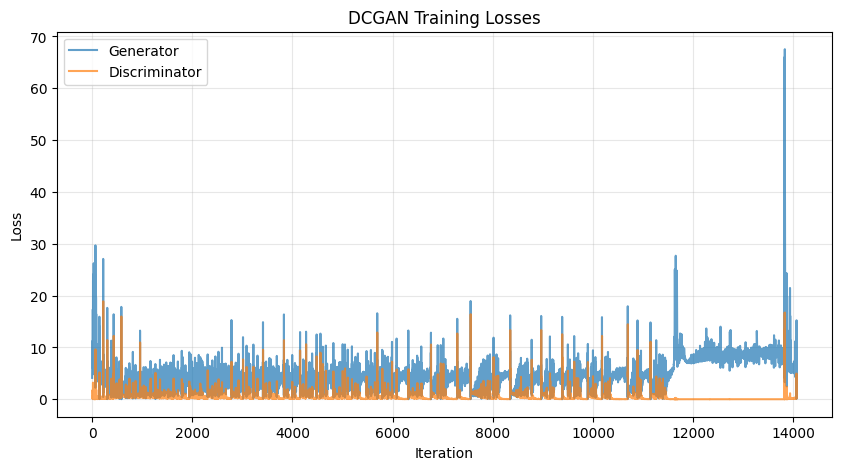

In [5]:
plt.figure(figsize=(10, 5))
plt.plot(g_losses, label='Generator', alpha=0.7)
plt.plot(d_losses, label='Discriminator', alpha=0.7)
plt.xlabel('Iteration')
plt.ylabel('Loss')
plt.title('DCGAN Training Losses')
plt.legend()
plt.grid(True, alpha=0.3)
plt.savefig(f'{OUTPUT_DIR}/loss_curve.png', dpi=120)
plt.show()
plt.close()

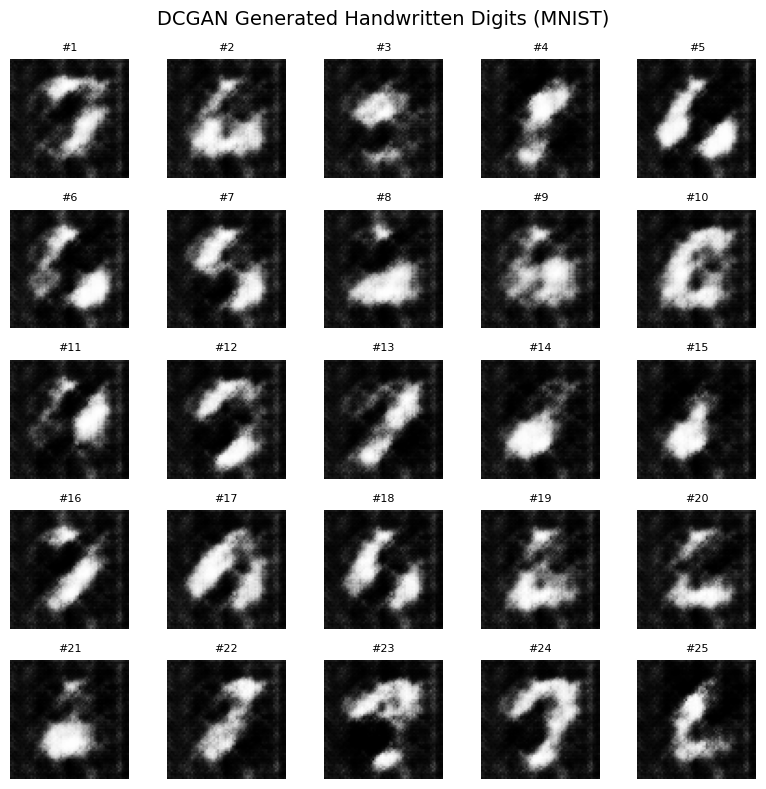

Done! Saved to outputs/final_generated_digits.png


In [6]:
G.eval()
noise = torch.randn(25, LATENT_DIM, 1, 1, device=device)
with torch.no_grad():
    samples = (G(noise).cpu() + 1) / 2
fig, axes = plt.subplots(5, 5, figsize=(8, 8))
for i, ax in enumerate(axes.flatten()):
    ax.imshow(samples[i, 0].numpy(), cmap='gray')
    ax.set_title(f'#{i+1}', fontsize=8)
    ax.axis('off')
fig.suptitle('DCGAN Generated Handwritten Digits (MNIST)', fontsize=14)
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/final_generated_digits.png', dpi=150, bbox_inches='tight')
plt.show()
print('Done! Saved to outputs/final_generated_digits.png')

In [7]:
import shutil
from google.colab import files

shutil.make_archive('dcgan_outputs', 'zip', 'outputs')
files.download('dcgan_outputs.zip')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [8]:
from google.colab import files

files.download('outputs/final_generated_digits.png')
files.download('outputs/loss_curve.png')
files.download('outputs/generator.pth')
files.download('outputs/discriminator.pth')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>